# 0. Saving & loading models

In [22]:
# Saving:

from datetime import datetime
model_path = f'dale_model_{datetime.now().strftime("%Y%m%d_%H%M%S")}.npz'
dale_model.save(model_path)

In [3]:
# Loading:

from src.training import PINning
dale_model, inputs = PINning.load('fulldale_model_pgd20260802_183851_p20_exc=80.npz')

# 1. Targets generation

In [1]:
import numpy as np
from src.targets_generation import Gaussian_seq

In [2]:
N = 500 # number of neurons
T = 10.5 # sequence length (in seconds)
dt = 0.001 # integration step (in seconds)
sigma = np.sqrt(0.3) # width of the gaussian curve
epsilon = 0.05

In [3]:
gs = Gaussian_seq(T, dt)
targets = gs.target_functions(T, sigma, N, epsilon)

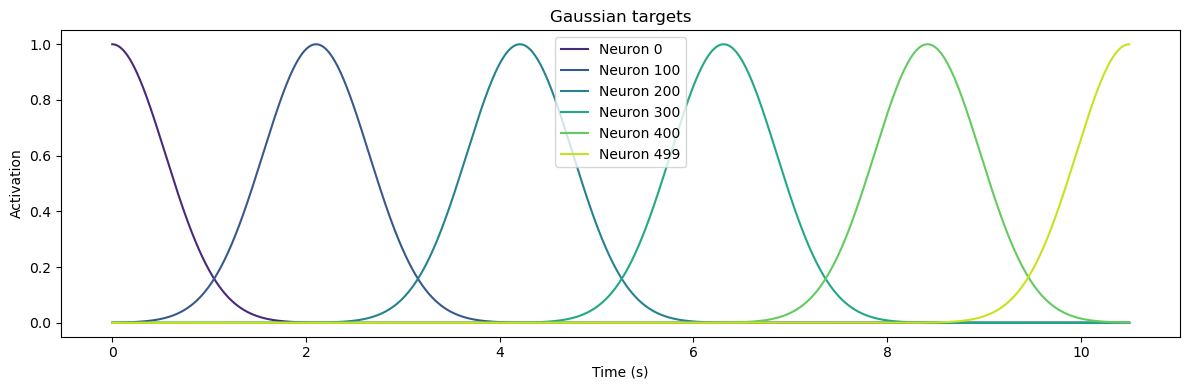

In [8]:
gs.gaussian_graph(T, sigma, N, neuron_list = [0, 100, 200, 300, 400, 499])

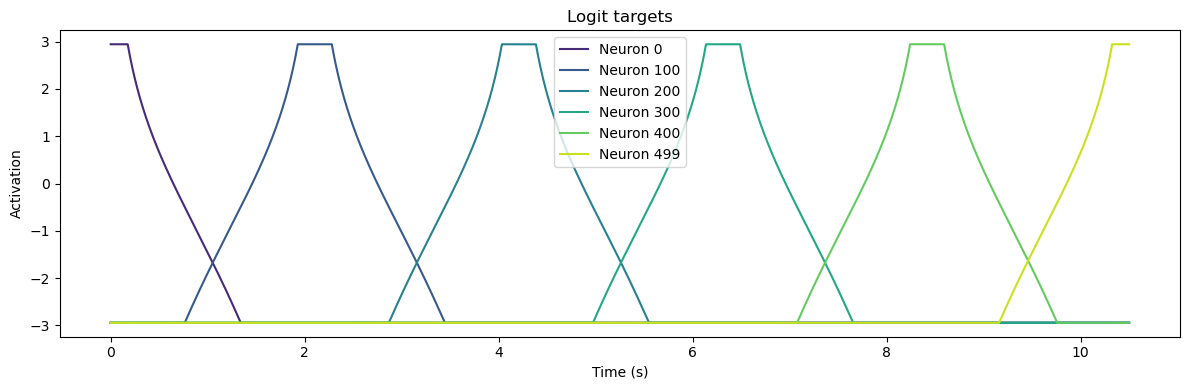

In [9]:
gs.target_graph(T, sigma, N, neuron_list = [0, 100, 200, 300, 400, 499], epsilon=epsilon)

# 2. Inputs generation

In [4]:
from src.inputs_generation import Inputs

In [5]:
WN_tau = 1  # inputs' correlation time (in seconds)
h0 = 0.15 # inputs' scale

In [6]:
ipt = Inputs(T, dt)
inputs = ipt.inputs(N, WN_tau, h0)

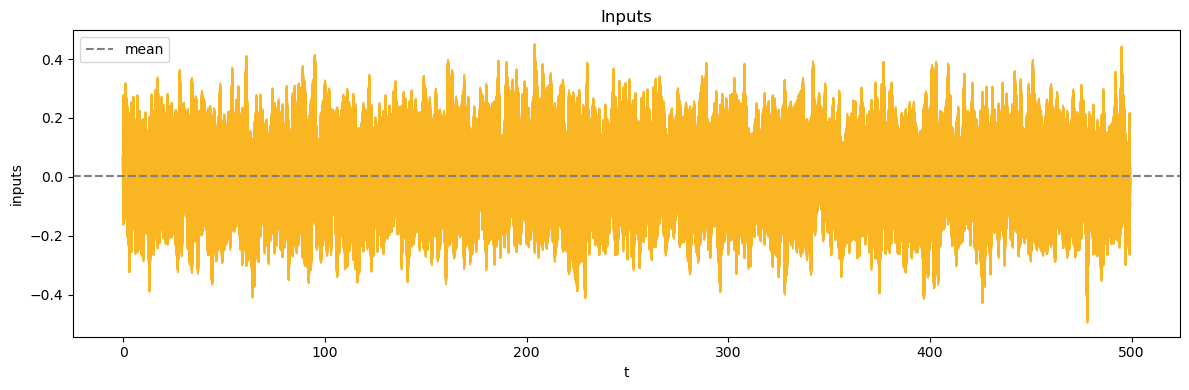

In [23]:
ipt.display_inputs(N, WN_tau, h0)

# 3. Unconstrained PINned model

### Training

In [7]:
from src.training import RNN, PINning

In [7]:
p = 0.2 # fraction of plastic synapses in the network
g = 1.2 # chaos parameter in [1.2, 1.5]
tau = 0.01 # membrane time constant (in seconds)
theta = 0 # sigmoid threshold
p0 = 10 # initial P matrix scaling factor: amplitude of 1 to 10 times h0
n_runs = 500 # number of training steps to learn J
n_steps = 50 # number of additionnal steps where J is not modified
cv_threshold = 0.02 # error value at which we deem the model to converge
p_reg = 1e-9 # Ridge regularization parameter

Run 1 | run_error=0.009894 | ||J||=398.18 | Δ||J||=+0.00
Run 2 | run_error=0.010308 | ||J||=466.29 | Δ||J||=+68.11
Run 3 | run_error=0.012259 | ||J||=491.79 | Δ||J||=+25.50
Run 4 | run_error=0.010016 | ||J||=506.37 | Δ||J||=+14.58
Run 5 | run_error=0.008747 | ||J||=522.75 | Δ||J||=+16.38
Run 6 | run_error=0.009167 | ||J||=534.88 | Δ||J||=+12.12
Run 7 | run_error=0.008947 | ||J||=539.91 | Δ||J||=+5.03
Run 8 | run_error=0.008368 | ||J||=549.25 | Δ||J||=+9.34
Run 9 | run_error=0.008152 | ||J||=554.85 | Δ||J||=+5.60
Run 10 | run_error=0.007010 | ||J||=564.02 | Δ||J||=+9.17
Run 11 | run_error=0.007916 | ||J||=567.86 | Δ||J||=+3.84
Run 12 | run_error=0.006174 | ||J||=580.44 | Δ||J||=+12.58
Run 13 | run_error=0.007394 | ||J||=584.18 | Δ||J||=+3.74
Run 14 | run_error=0.008766 | ||J||=598.01 | Δ||J||=+13.83
Run 15 | run_error=0.006878 | ||J||=603.55 | Δ||J||=+5.54
Run 16 | run_error=0.005598 | ||J||=610.52 | Δ||J||=+6.97
Run 17 | run_error=0.007576 | ||J||=616.53 | Δ||J||=+6.01
Run 18 | run_err

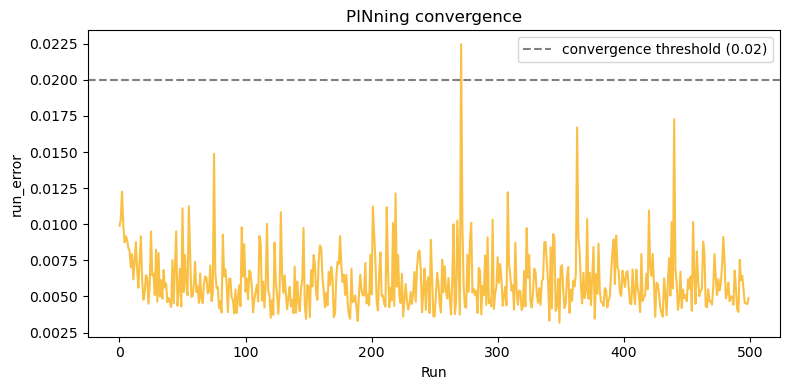

In [12]:
rnn = RNN(N, g, dt, tau, theta, p0)
PINned_model = PINning(p, rnn, targets, p0)
errors, j_norms = PINned_model.train(inputs, n_runs, cv_threshold, DEBUG = True, p_reg=p_reg)
PINned_model.display_cv(errors)

### Simulation

In [13]:
final_rates = PINned_model.simulate(inputs, n_steps=n_steps)

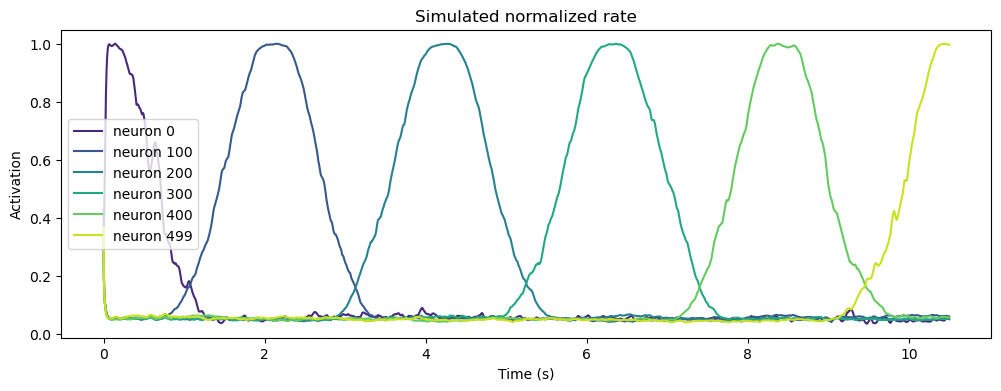

In [14]:
neuron_list = [0, 100, 200, 300, 400, 499]
PINned_model.display_simulation(T, dt, final_rates, neuron_list)

### Evaluation

In [14]:
threshold = 0.95

In [15]:
from src.evaluation import Metrics

In [16]:
from scipy.special import expit
targets_rate = expit(targets)
Metrics.general_evaluation(rates = final_rates, targets = targets_rate, t = gs.t, sigma = sigma, threshold = threshold)

,,bVar,pVar,Qeff
0,Model's metrics,0.359363,0.572985,6
1,Article's metrics for p=0.08,1,0.92,10


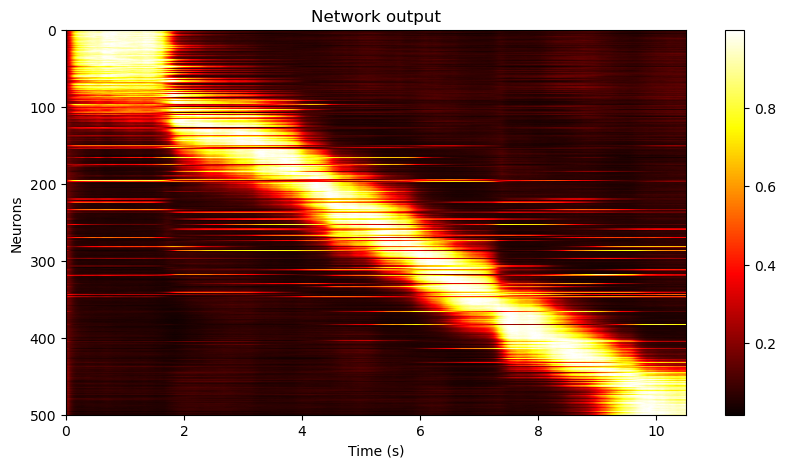

In [17]:
Metrics.network_output(final_rates, T, dt)

### Synaptic strength distribution

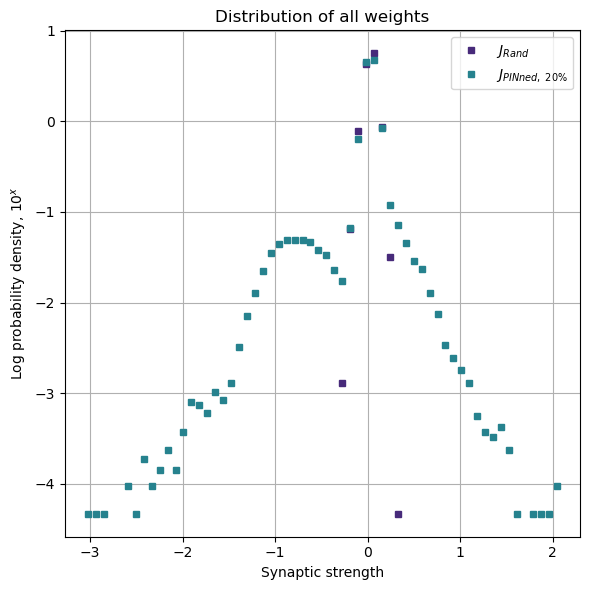

In [18]:
dale_model.display_weight_distribution(value = 'all', bins=60)

# 4. PINning constrained by Dale's principle

In [8]:
from src.training import Dale_PINning, RNN

In [10]:
g = 1.5
p = 0.2
n_runs = 1500
p_exc = 0.8
lam = 0 # lam=400 for fnnls & bptt, lam=0 for pgd
eta = 1e-5
eta_decay = 0.01
K=200

rnn = RNN(N, g, dt, tau, theta, p0)
dale_model = Dale_PINning(p, rnn, targets, p0)

Run 1/1500 | run_error=42.325081 | ||J||=56.40
Run 2/1500 | run_error=2.757510 | ||J||=56.50
Run 3/1500 | run_error=2.710918 | ||J||=56.62
Run 4/1500 | run_error=2.681563 | ||J||=56.73
Run 5/1500 | run_error=2.665527 | ||J||=56.85
Run 6/1500 | run_error=2.655326 | ||J||=56.96
Run 7/1500 | run_error=2.648954 | ||J||=57.08
Run 8/1500 | run_error=2.643894 | ||J||=57.19
Run 9/1500 | run_error=2.641959 | ||J||=57.30
Run 10/1500 | run_error=2.638969 | ||J||=57.41
Run 11/1500 | run_error=2.637220 | ||J||=57.52
Run 12/1500 | run_error=2.635454 | ||J||=57.63
Run 13/1500 | run_error=2.633873 | ||J||=57.74
Run 14/1500 | run_error=2.632401 | ||J||=57.84
Run 15/1500 | run_error=2.630914 | ||J||=57.94
Run 16/1500 | run_error=2.629468 | ||J||=58.04
Run 17/1500 | run_error=2.628197 | ||J||=58.14
Run 18/1500 | run_error=2.627039 | ||J||=58.24
Run 19/1500 | run_error=2.626327 | ||J||=58.34
Run 20/1500 | run_error=2.624955 | ||J||=58.44
Run 21/1500 | run_error=2.623792 | ||J||=58.53
Run 22/1500 | run_err

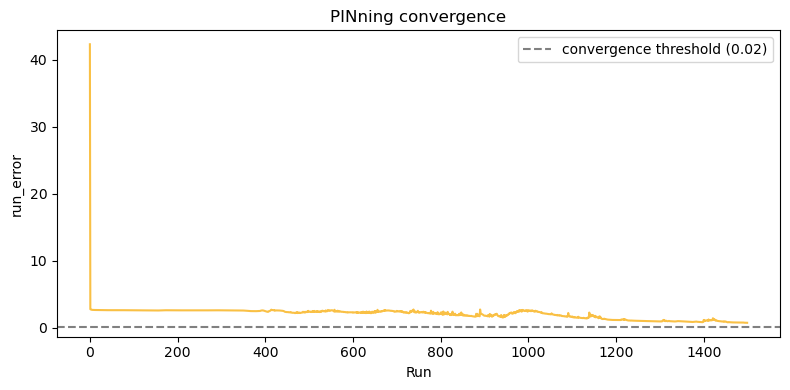

In [11]:
dale_model.set_dale_constraint_mixed(p_exc, p_exc)
errors, j_norms = dale_model.train_dale_bptt(inputs, n_runs, eta, cv_threshold, K, lam, eta_decay, DEBUG=True, x_init_scale=0.1)
dale_model.display_cv(errors)

In [12]:
final_rates = dale_model.simulate(inputs, n_steps=50)

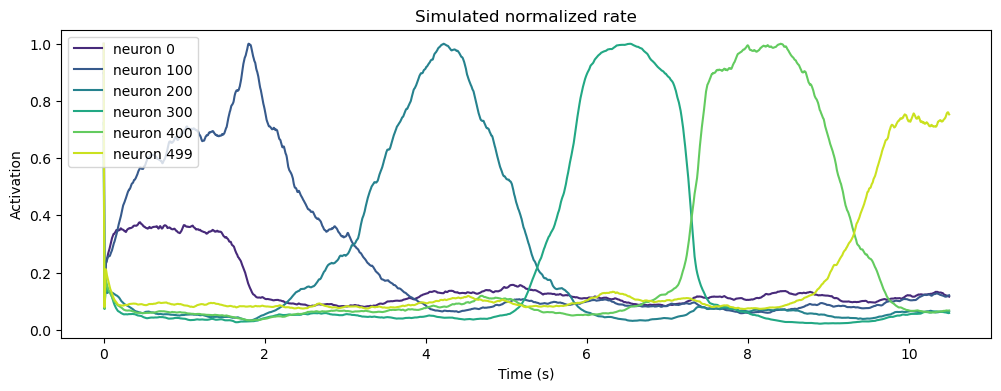

In [21]:
neuron_list = [0, 100, 200, 300, 400, 499]
dale_model.display_simulation(T, dt, final_rates, neuron_list)